# Point Cloud Optimization

In [1]:
import multipers as mp
from multipers.data import noisy_annulus, three_annulus
import gudhi as gd
import numpy as np
import matplotlib.pyplot as plt
import torch
# t.autograd.set_detect_anomaly(True)
from multipers.plots import plot_signed_measures, plot_signed_measure
from tqdm import tqdm
torch.manual_seed(1)
np.random.seed(1)

## Spatially localized optimization

The goal of this notebook is to generate cycles on the modes of a fixed measure. 

In this example, the measure is defined (in the cell below) as a sum of 3 gaussian measures.

In [2]:
## The density function of the measure
def custom_map(x, sigma=.17, threshold=None):
    if x.ndim == 1:
        x = x[None,:]
    assert x.ndim ==2
    basepoints = torch.tensor([[0.2,0.2], [0.8, 0.4], [0.4, 0.7]]).T
    out = -(torch.exp( - (((x[:,:,None]- basepoints[None,:,:]) / sigma).square() ).sum(dim=1) )).sum(dim=-1)
    return 1+out

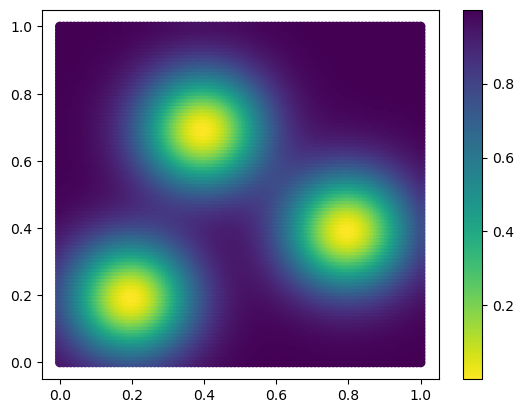

In [3]:
x= np.linspace(0,1,100)
mesh = np.meshgrid(x,x)
coordinates = np.concatenate([stuff.flatten()[:,None] for stuff in mesh], axis=1)
coordinates = torch.from_numpy(coordinates)
plt.scatter(*coordinates.T,c=custom_map(coordinates), cmap="viridis_r")
plt.colorbar()

We start from a uniform point cloud, that we will optimize

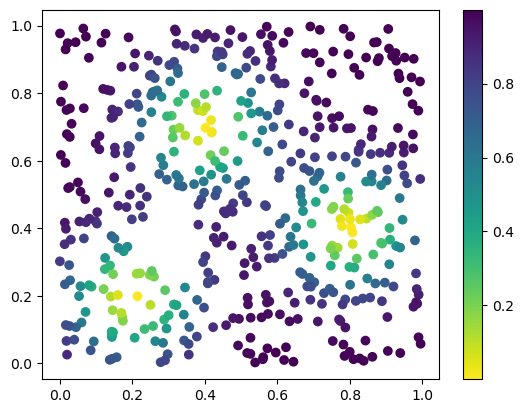

In [4]:
x = np.random.uniform(size=(500,2))
x = torch.tensor(x, requires_grad=True)
plt.scatter(*x.detach().numpy().T, c=custom_map(x).detach().numpy(), cmap="viridis_r")
plt.colorbar()

The usual filtration functions (e.g.,
[`RipsLowerstar`](../filtrations/rips.ipynb),
[`Cubical`](../filtrations/cubical.ipynb),
[`DelaunayLowerstar`](../filtrations/function_delaunay.ipynb)) automatically
detect the differentiability of the input, and propagate the gradient in that
case.
Nothing changes !

/Users/dlapous/micromamba/envs/313/lib/python3.13/site-packages/gudhi/simplex_tree.py:122: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1769768019679/work/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  ret._insert_matrix(filtrations, max_filtration)


True


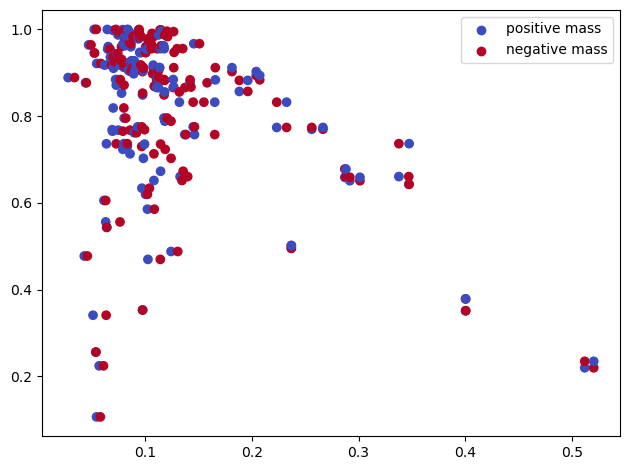

In [5]:
x = np.random.uniform(size=(300,2))
x = torch.tensor(x, requires_grad=True)
from multipers.filtrations import RipsLowerstar, DelaunayLowerstar
# st = DelaunayLowerstar(points=x,function=custom_map(x), flagify=True)
st = RipsLowerstar(points=x,function=custom_map(x))
st.collapse_edges(-1) # litte preprocessing
st.expansion(2)       # adding 2-dimensional simplices are necessary for H1
sm_diff, = mp.signed_measure(st, degree=1, plot=True)
print(sm_diff[0].requires_grad) # Should be true

For this example we use the following loss. Given a signed measure $\mu$, define 

$$\mathrm{loss}(\mu) := \int\varphi(x) d\mu(x)$$ 

where $x := (r,d)\in \mathbb R^2$ ($r$ for radius, and $d$ for codensity value of the original measure) 
$$\varphi(x) = \varphi(r,d) = r\times(\mathrm{threshold}-d)$$

This can be interpreted as follows : 
 - we maximise the radius of the negative point (maximizing the radius of cycles)
 - we minimize the radius of positive points (the edges of the connected points creating the cycles). This create pretty cycles
 - we care more about cycles that are close to the mode (the `threshold-d` part). 
 The threshold is meant to prevent the cycles that are not close enough the the cycles to progressively stop to create loops.

In [6]:
threshold = .65
def softplus(x):
    return torch.log(1+torch.exp(x))
# @torch.compile(dynamic=True)
def loss_function(x,sm):
    pts,weights = sm
    radius,density = pts.T
    density = density
    
    phi = lambda x,d : (
        x
        * (threshold-d)
    ).sum()
    loss = phi(radius[weights>0], density[weights>0]) - phi(radius[weights<0], density[weights<0])
    return loss

loss_function(x,sm_diff) #test that it work. It should make no error + have a gradient

tensor(0.2417, dtype=torch.float64, grad_fn=<SubBackward0>)

As [Delaunay complexes](../filtrations/function_delaunay.ipynb) are faster to
use in low-dimensional Euclidean space, we switch from Rips to Delaunay and
optimize this `loss_function`.

Another optimization would be to copy the simplextree into a slicer, on which
it is possible to compute a
[minimal presentation](../ops/minimal_presentations_resolutions.ipynb).
Computing the [Hilbert function](../invariants/hilbert_function.ipynb) is quite
fast, so this will not lead to a significant improvement, but consider this
optimization when computing harder
[invariants](../invariants/signed_measure.ipynb).

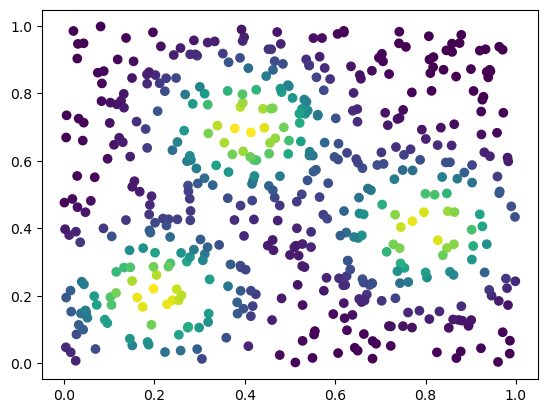

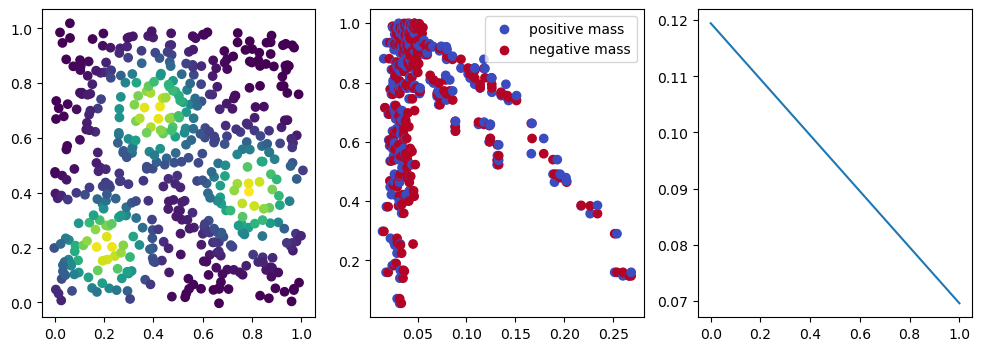

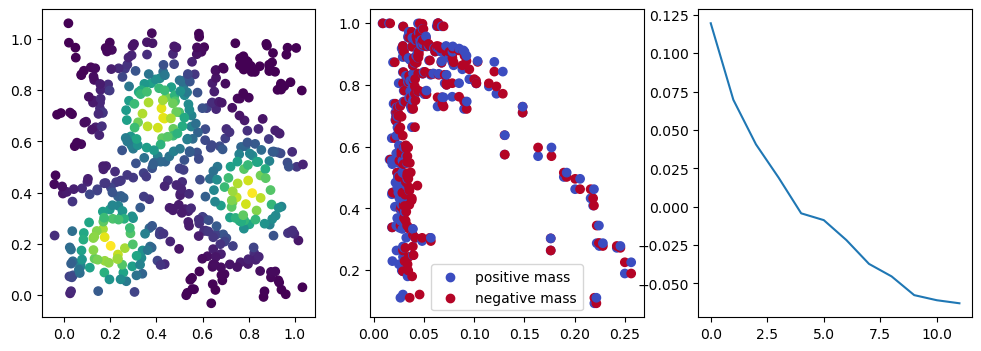

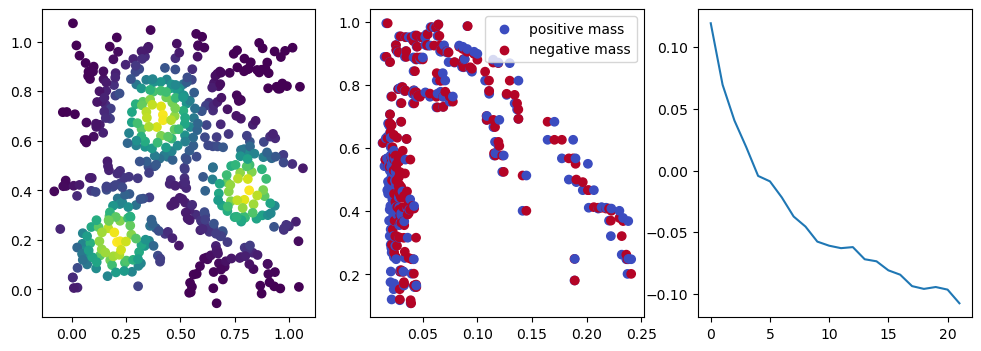

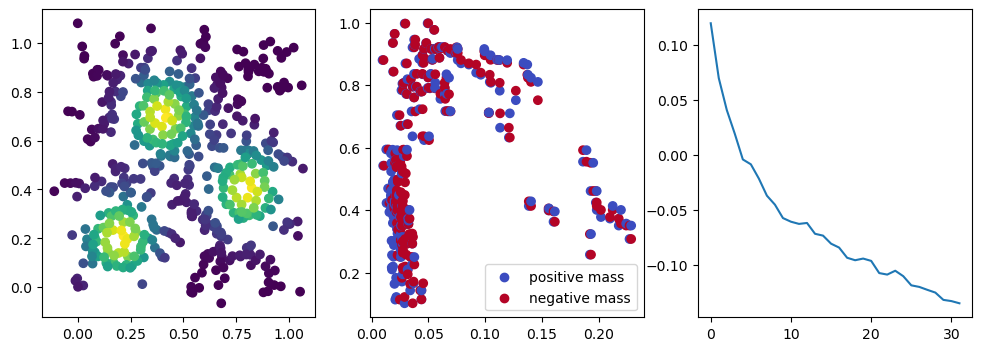

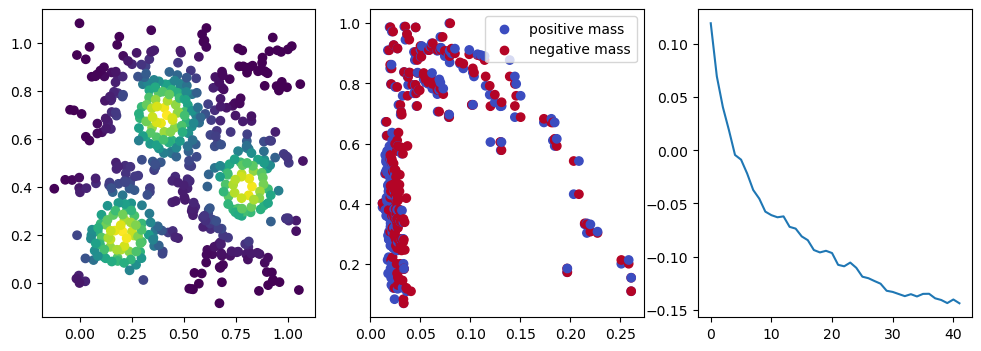

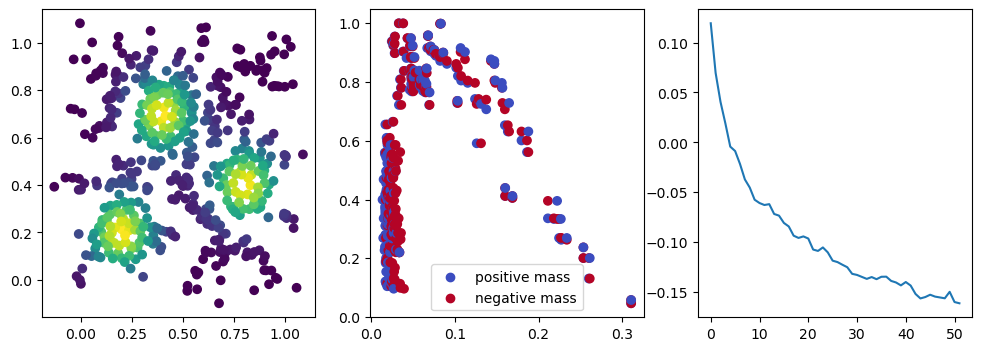

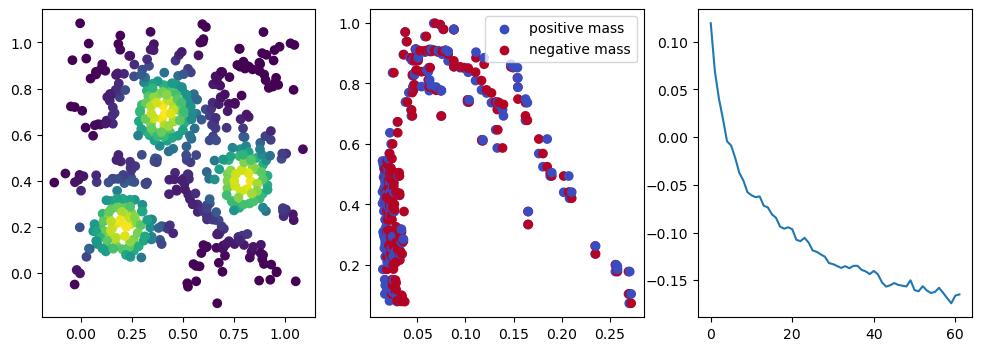

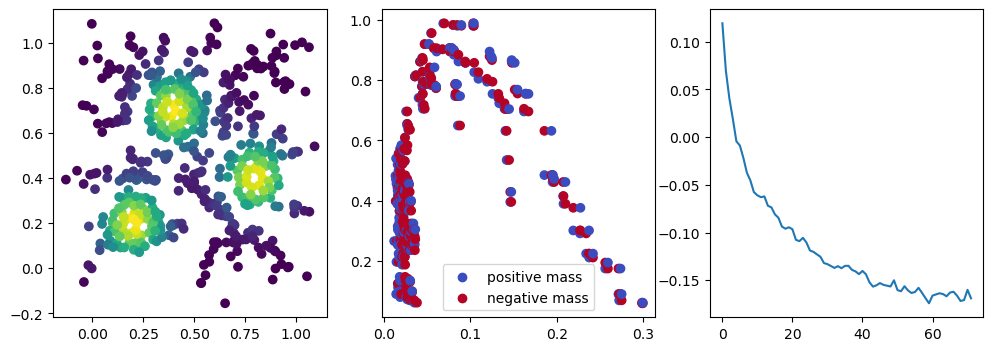

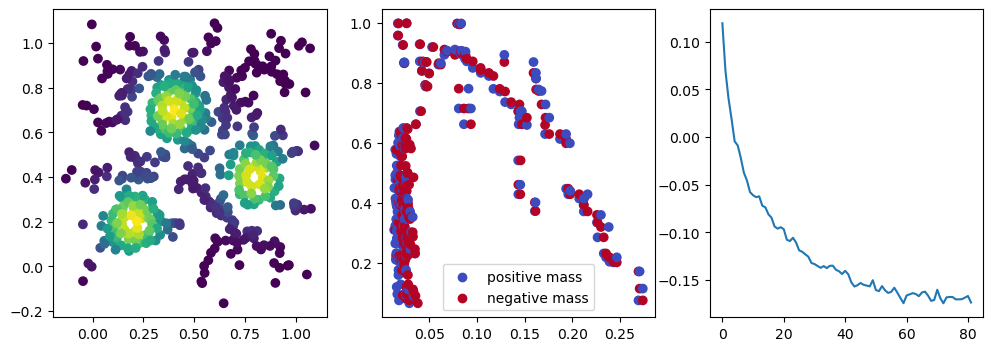

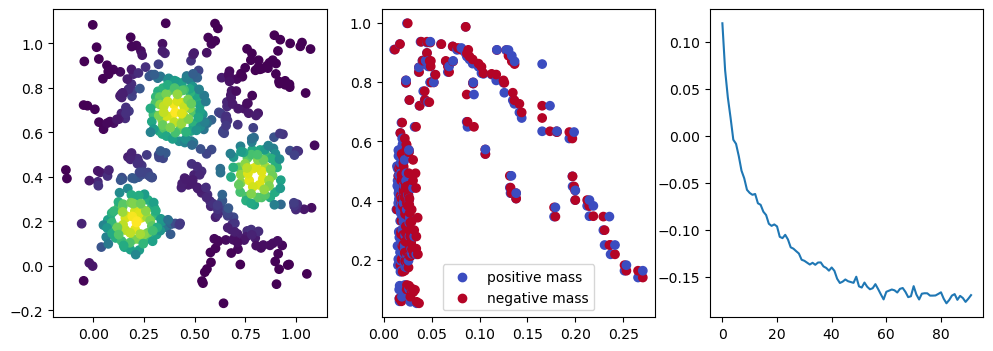

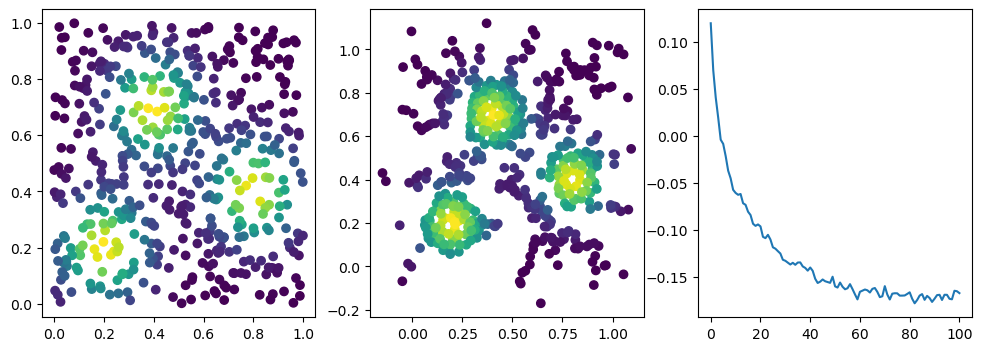

In [7]:
from multipers.filtrations import DelaunayLowerstar
xinit = np.random.uniform(size=(500,2)) # initial dataset
x = torch.tensor(xinit, requires_grad=True)
adam = torch.optim.Adam([x], lr=0.01) #optimizer
losses = []
plt.scatter(*x.detach().numpy().T, c=custom_map(x, threshold=np.inf).detach().numpy(), cmap="viridis_r")
plt.show()
for i in range(101): # gradient steps
    # Little caveat of Delaunay, they are hard to differentiate. 
    # We hence weaken the delaunay complex into a flag complex, which is easier to differentiate, 
    # with the `flagify=True` flag.
    st = DelaunayLowerstar(points=x, function=custom_map(x), flagify=True)
    sm_diff, = mp.signed_measure(st, degree=1)

    # Rips version
    # st = RipsLowerstar(points=x,function=custom_map(x))
    # st.collapse_edges(-1)
    # st.expansion(2)
    # sm_diff, = mp.signed_measure(st, degree=1)
    
    adam.zero_grad()
    loss = loss_function(x,sm_diff)
    loss.backward()
    adam.step()
    losses.append([loss.detach().numpy()])
    with torch.no_grad():
        if i %10 == 1: #plot part
            base=4
            ncols=3
            fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=ncols, figsize=(ncols*base, base))
            ax1.scatter(*x.detach().numpy().T, c=custom_map(x, threshold=np.inf).detach().numpy(), cmap="viridis_r", )
            plot_signed_measure(sm_diff, ax=ax2)
            ax3.plot(losses, label="loss")
            plt.show()
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=ncols, figsize=(ncols*base, base))
ax1.scatter(*xinit.T, c=custom_map(torch.tensor(xinit)).detach().numpy(),cmap="viridis_r")
ax2.scatter(*x.detach().numpy().T, c=custom_map(x).detach().numpy(),cmap="viridis_r")
ax3.plot(losses)

plt.show()

We now observe an onion-like structure around the poles of the background measure.

How to interpret this ? The density constraints (in the loss) and the radius constraints are fighting against each other, 
therefore, each cycle has to balance itself to a local optimal, which leads to these onion layers.

## Density preserving optimization 

Example taken from the paper [Differentiability and Optimization of Multiparameter Persistent Homology](https://icml.cc/virtual/2024/poster/33331),
and is an extension of the point cloud experiement of [the optimization Gudhi notebook](https://github.com/GUDHI/TDA-tutorial/blob/master/Tuto-GUDHI-optimization.ipynb).
<br>
One can check from the Gudhi's notebook that a compacity regularization term is necessary in the one parameter persistence setting; this issue will not happen when optimizing a Rips-Density bi-filtration, as we can enforce cycles to naturally balance between scale and density, and hence not diverge.

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


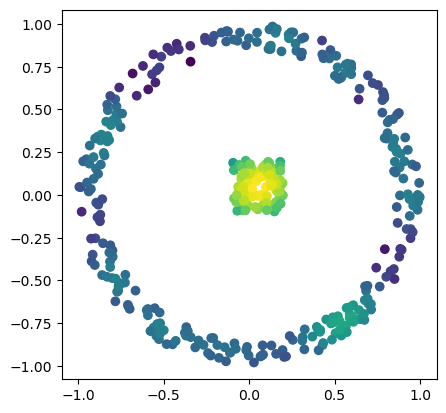

In [8]:
from multipers.filtrations.density import KDE
X = np.block([
    [np.random.uniform(low=-0.1,high=.2,size=(100,2))],
    [mp.data.noisy_annulus(300,0, 0.85,1)]
])
bandwidth = .1
custom_map2 = lambda X :  -KDE(bandwidth=bandwidth, return_log=True).fit(X).score_samples(X)
codensity = custom_map2(X)
plt.scatter(*X.T, c=-codensity)
plt.gca().set_aspect(1)

In [9]:
def norm_loss(sm_diff,norm=1.):
    pts,weights = sm_diff
    loss = (torch.norm(pts[weights>0], p=norm, dim=1)).sum() -  (torch.norm(pts[weights<0], p=norm, dim=1)).sum()
    return loss / pts.shape[0]

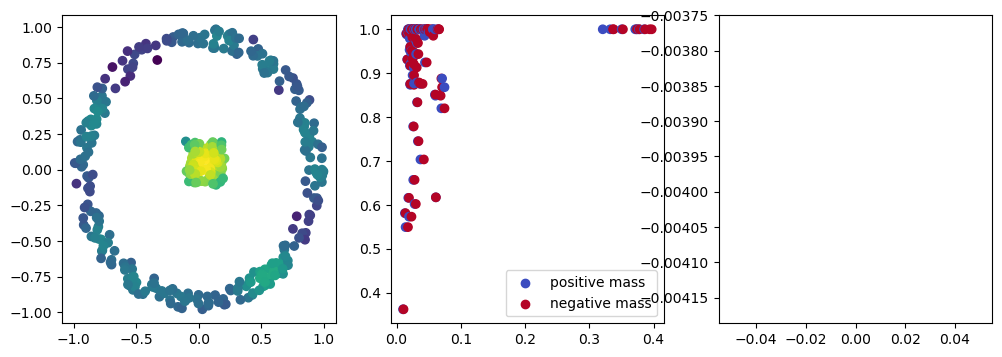

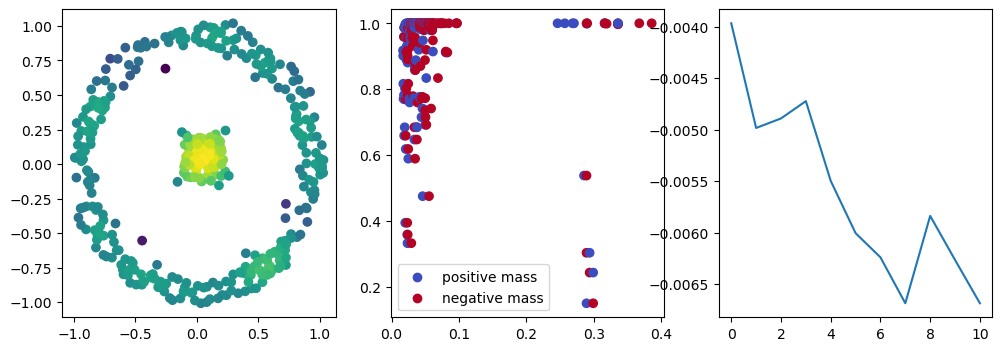

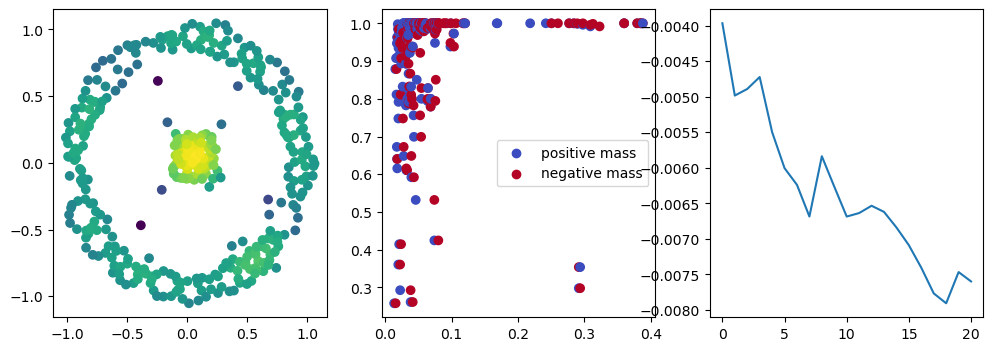

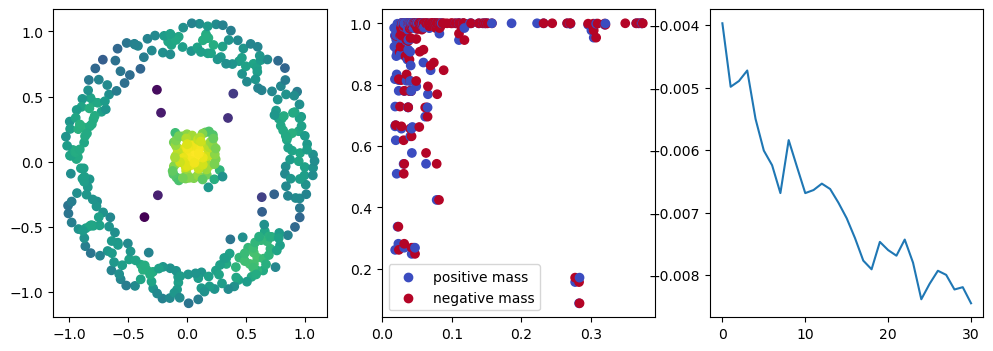

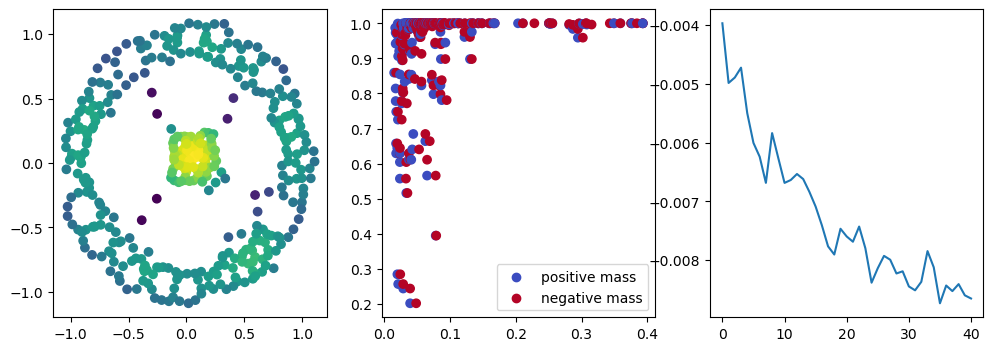

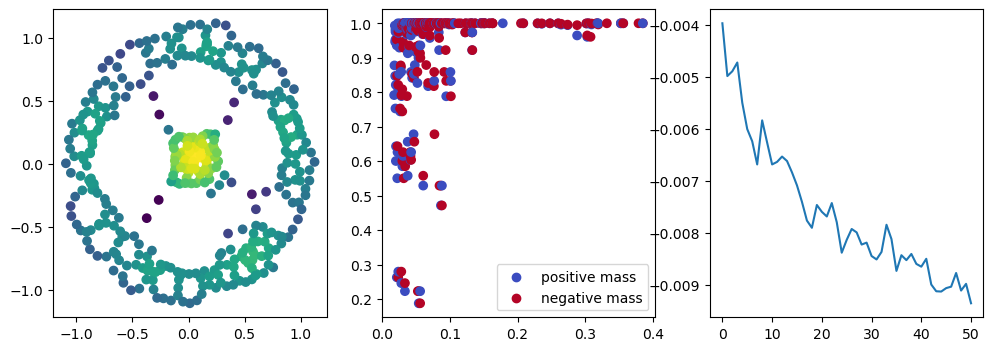

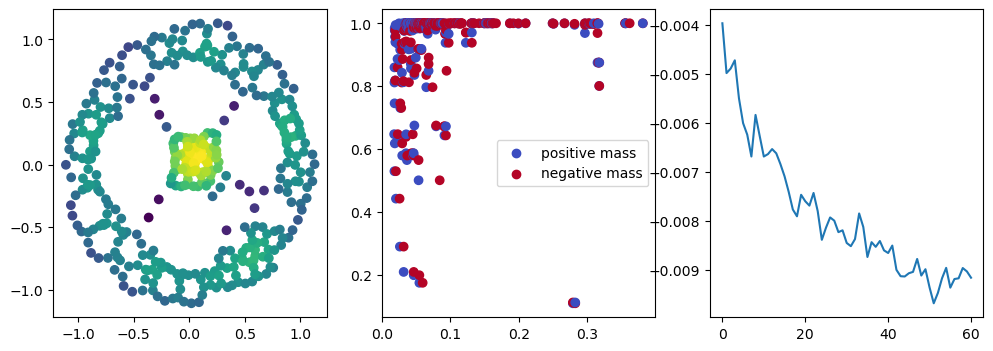

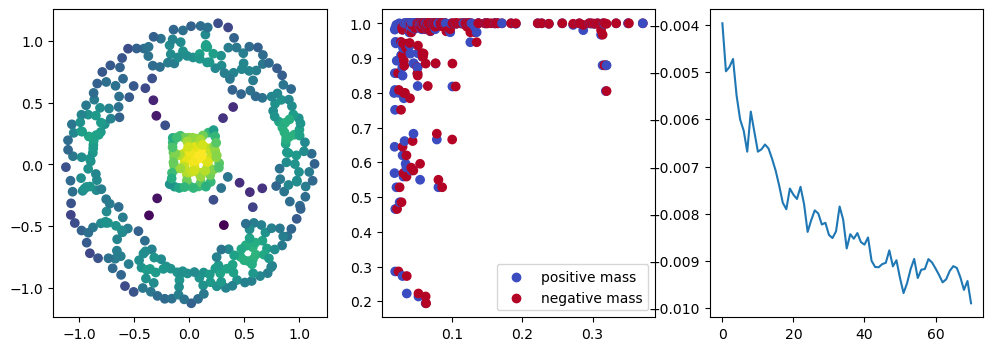

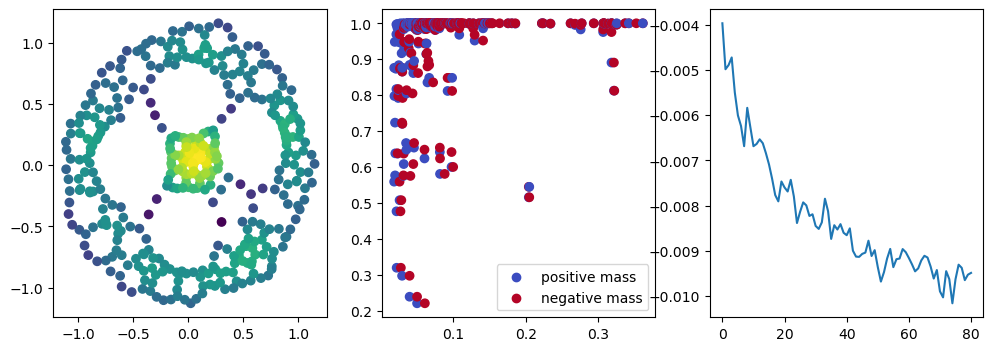

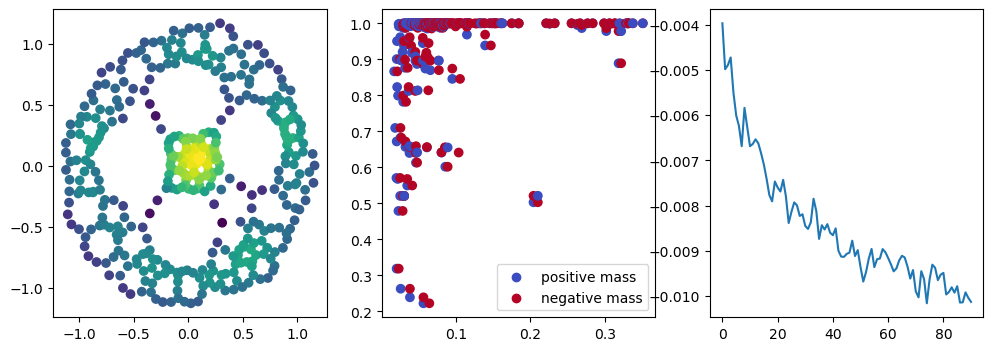

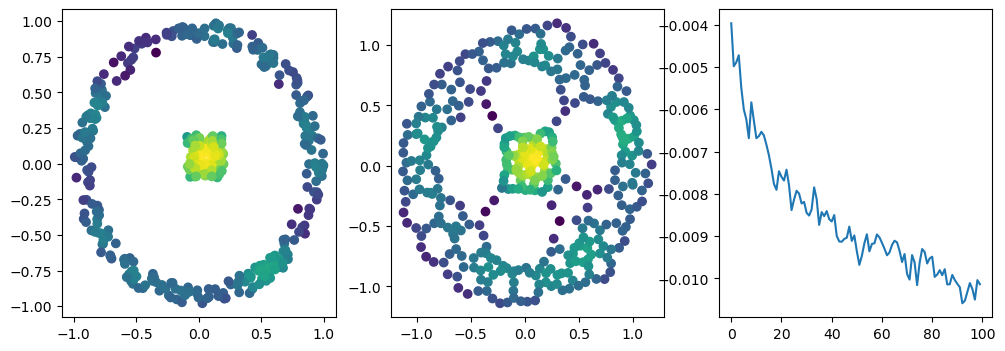

In [10]:
x = torch.from_numpy(X).clone().requires_grad_(True)
opt = torch.optim.Adam([x], lr=.01)
losses = []
for i in range(100):
    opt.zero_grad()
    st = DelaunayLowerstar(points=x, function=custom_map(x), flagify=True)
    sm_diff, = mp.signed_measure(st, degree=1)
    loss = norm_loss(sm_diff)
    loss.backward()
    losses.append(loss)
    opt.step()
    if i % 10 == 0:
    	with torch.no_grad():
            base=4
            ncols=3
            fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=ncols, figsize=(ncols*base, base))
            ax1.scatter(*x.detach().numpy().T, c=custom_map2(x).detach().numpy(), cmap="viridis_r", )
            plot_signed_measure(sm_diff, ax=ax2)
            ax3.plot(losses, label="loss")
            plt.show()

with torch.no_grad():
    fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=ncols, figsize=(ncols*base, base))
    ax1.scatter(*X.T, c=custom_map2(torch.tensor(X)).detach().numpy(),cmap="viridis_r")
    ax2.scatter(*x.detach().numpy().T, c=custom_map2(x).detach().numpy(),cmap="viridis_r")
    ax3.plot(losses)
    plt.show()